【系統通知】資料集讀取成功！資料筆數與欄位數： (2111, 17)


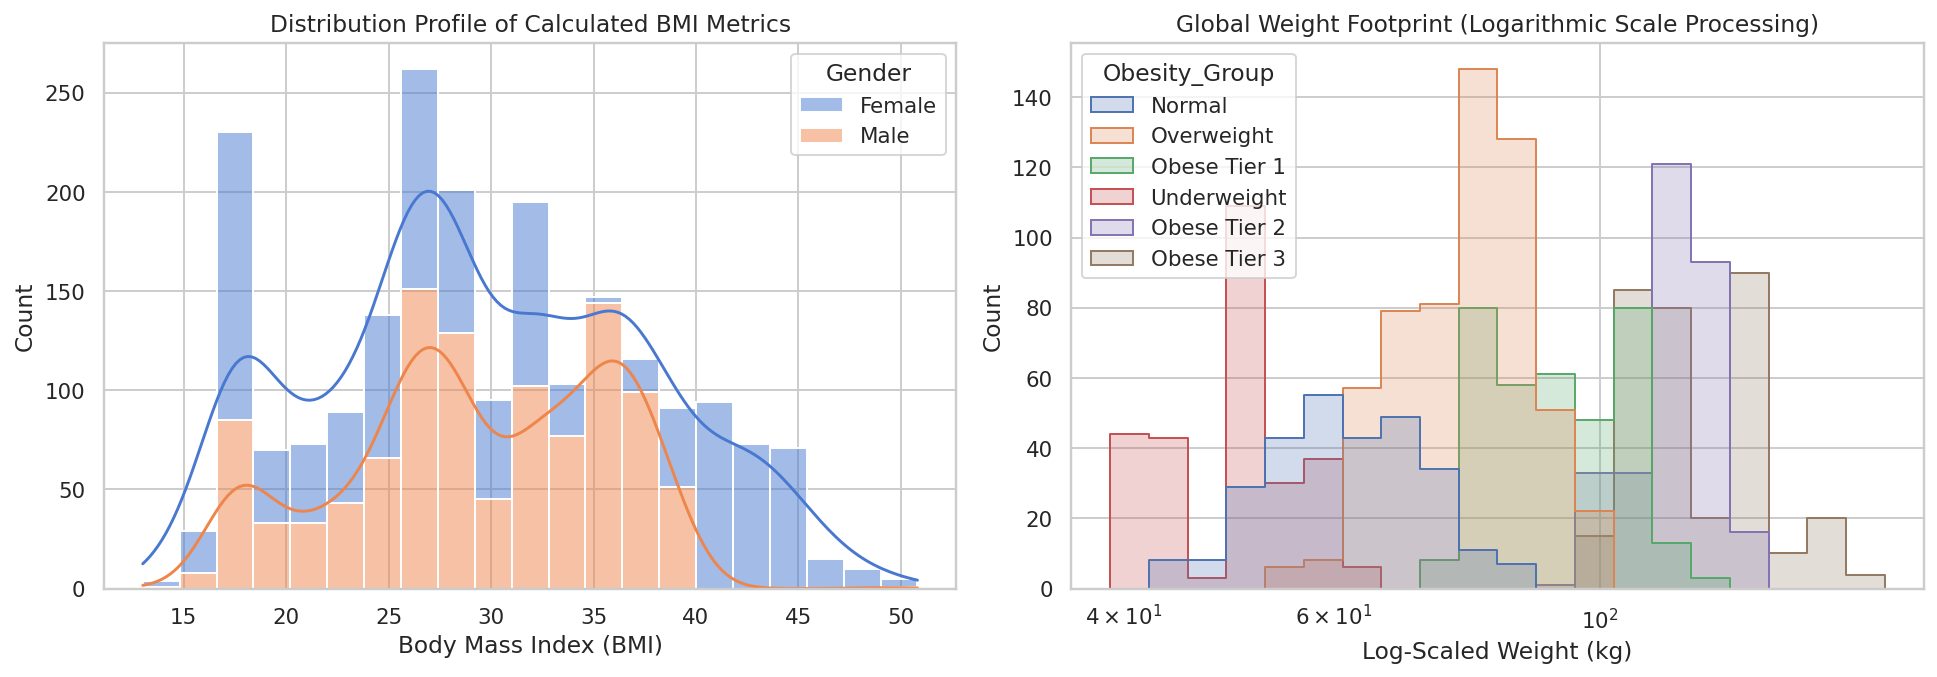

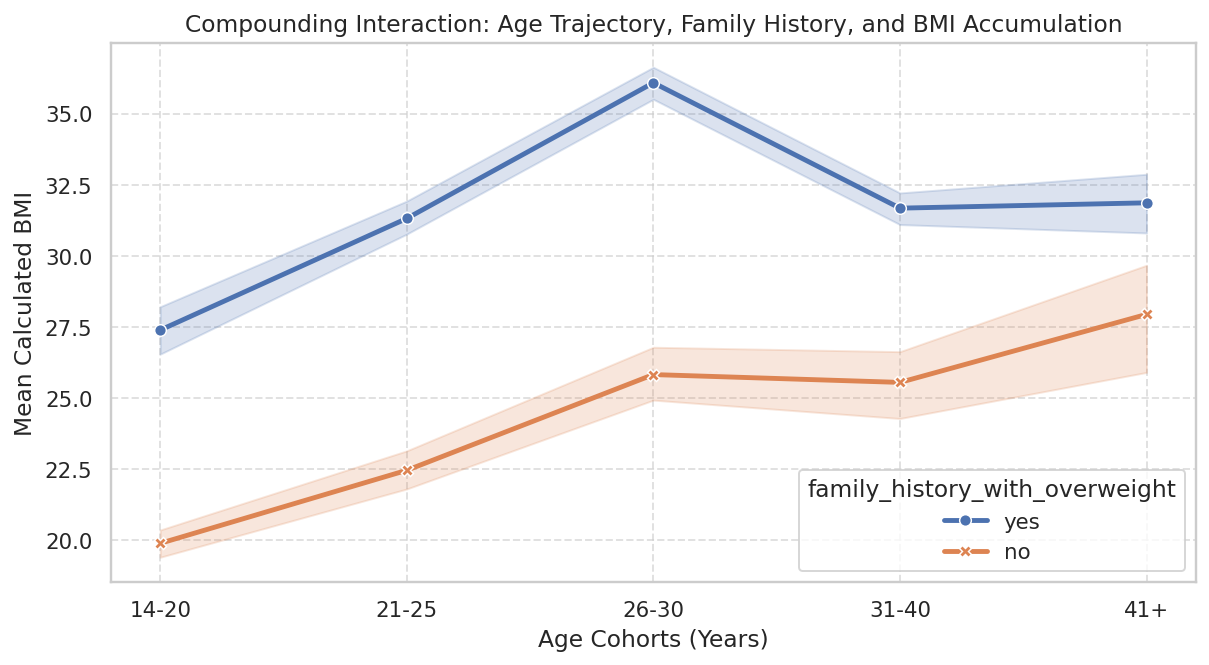

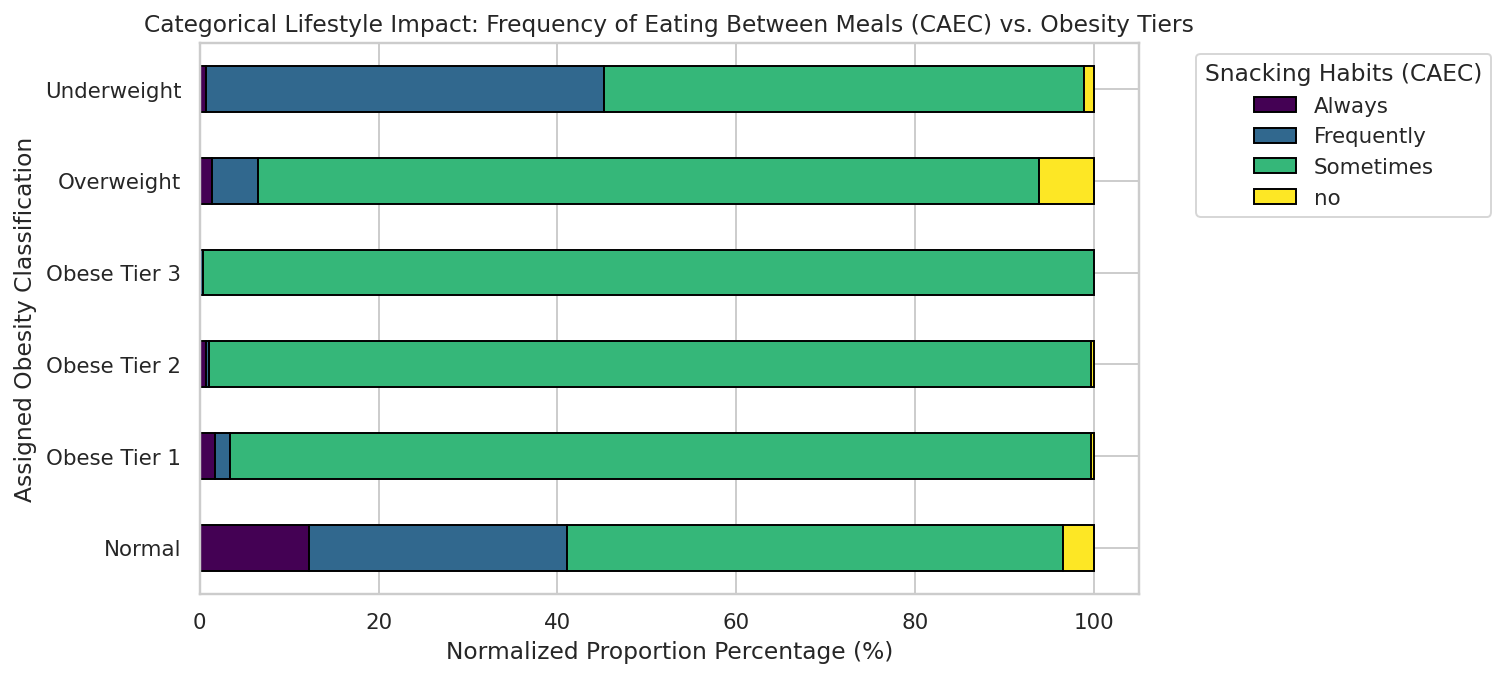

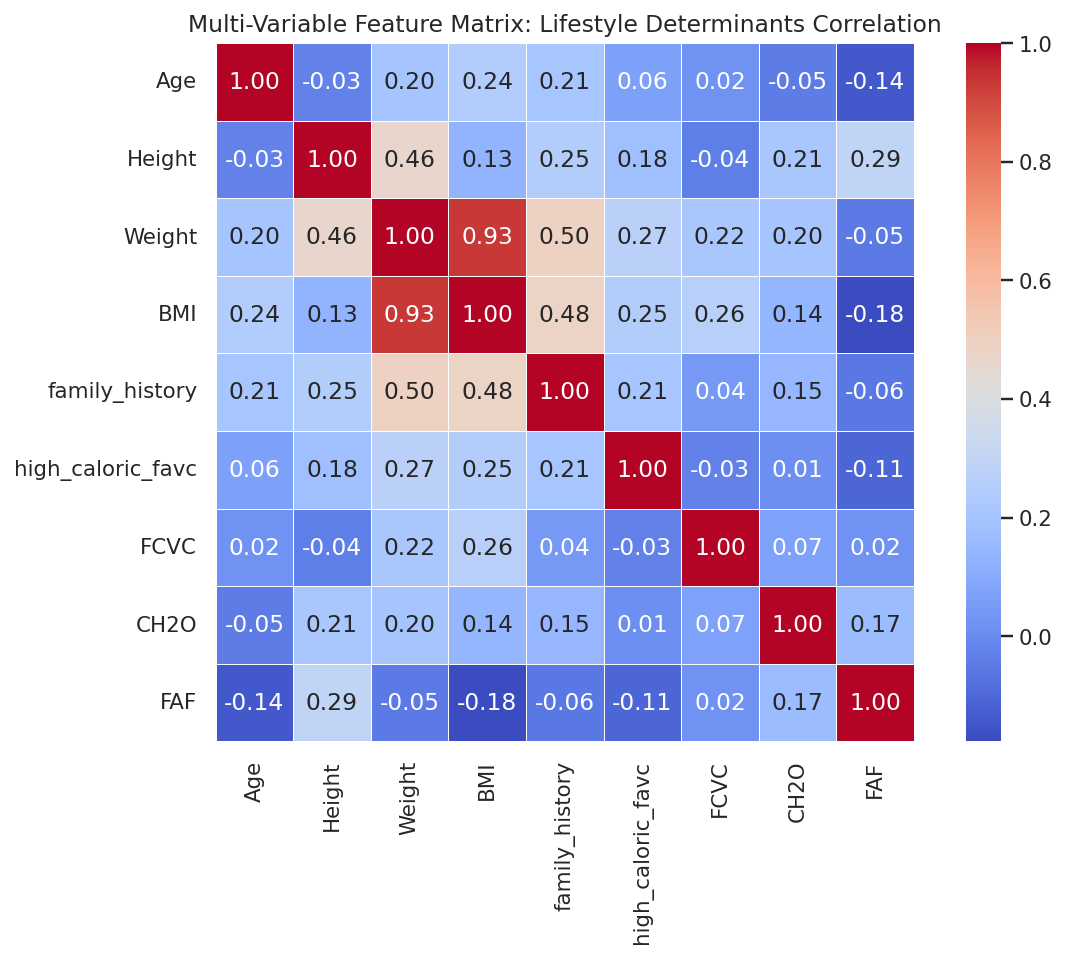

【系統通知】清洗後的檔案已成功匯出存檔！


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['figure.dpi'] = 140

try:
    df_raw = pd.read_csv('/content/ObesityDataSet_raw_and_data_sinthetic.csv')
    print("【系統通知】資料集讀取成功！資料筆數與欄位數：", df_raw.shape)
except Exception as e:
    print(f"【系統錯誤】找不到檔案，請確認是否已將 CSV 檔案上傳至 Colab：{e}")

def process_and_pivot_lifestyle_data(df):
    df = df.copy()

    df['BMI'] = df['Weight'] / (df['Height'] ** 2)

    obesity_mapping = {
        'Insufficient_Weight': 'Underweight', 'Normal_Weight': 'Normal',
        'Overweight_Level_I': 'Overweight', 'Overweight_Level_II': 'Overweight',
        'Obesity_Type_I': 'Obese Tier 1', 'Obesity_Type_II': 'Obese Tier 2', 'Obesity_Type_III': 'Obese Tier 3'
    }
    df['Obesity_Group'] = df['NObeyesdad'].map(obesity_mapping)

    grouped_summary = df.groupby(['Obesity_Group', 'Gender'])[['Age', 'BMI', 'CH2O', 'FAF']].mean().reset_index()

    melted_lifestyle = pd.melt(
        df,
        id_vars=['Obesity_Group', 'Gender', 'BMI'],
        value_vars=['CH2O', 'FAF', 'TUE'],
        var_name='Lifestyle_Factor',
        value_name='Factor_Value'
    )
    return df, grouped_summary, melted_lifestyle

df_clean, df_grouped, df_melted = process_and_pivot_lifestyle_data(df_raw)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df_clean, x='BMI', hue='Gender', kde=True, multiple="stack", ax=axes[0], palette="muted")
axes[0].set_title("Distribution Profile of Calculated BMI Metrics")
axes[0].set_xlabel("Body Mass Index (BMI)")

sns.histplot(data=df_clean, x='Weight', hue='Obesity_Group', kde=False, ax=axes[1], log_scale=True, element="step")
axes[1].set_title("Global Weight Footprint (Logarithmic Scale Processing)")
axes[1].set_xlabel("Log-Scaled Weight (kg)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
df_clean['Age_Bin'] = pd.cut(df_clean['Age'], bins=[14, 20, 25, 30, 40, 61], labels=['14-20', '21-25', '26-30', '31-40', '41+'])
sns.lineplot(data=df_clean, x='Age_Bin', y='BMI', hue='family_history_with_overweight',
             style='family_history_with_overweight', markers=True, dashes=False, err_style="band", linewidth=2.5)
plt.title("Compounding Interaction: Age Trajectory, Family History, and BMI Accumulation")
plt.xlabel("Age Cohorts (Years)")
plt.ylabel("Mean Calculated BMI")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

cross_tab = pd.crosstab(df_clean['Obesity_Group'], df_clean['CAEC'], normalize='index') * 100
cross_tab.plot(kind='barh', stacked=True, cmap='viridis', edgecolor='black', figsize=(11, 5))
plt.title("Categorical Lifestyle Impact: Frequency of Eating Between Meals (CAEC) vs. Obesity Tiers")
plt.xlabel("Normalized Proportion Percentage (%)")
plt.ylabel("Assigned Obesity Classification")
plt.legend(title="Snacking Habits (CAEC)", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 7))
numeric_corr_df = df_clean.copy()
numeric_corr_df['family_history'] = numeric_corr_df['family_history_with_overweight'].map({'yes': 1, 'no': 0})
numeric_corr_df['high_caloric_favc'] = numeric_corr_df['FAVC'].map({'yes': 1, 'no': 0})
matrix_features = ['Age', 'Height', 'Weight', 'BMI', 'family_history', 'high_caloric_favc', 'FCVC', 'CH2O', 'FAF']
correlation_matrix = numeric_corr_df[matrix_features].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=.5)
plt.title("Multi-Variable Feature Matrix: Lifestyle Determinants Correlation", fontsize=12)
plt.tight_layout()
plt.show()

df_clean.to_csv('Obesity_Data_Cleaned_Processed.csv', index=False, encoding='utf-8')
df_grouped.to_csv('Obesity_Demographic_Group_Summary.csv', index=False, encoding='utf-8')
print("【系統通知】清洗後的檔案已成功匯出存檔！")